# 1. Importação das Bibliotecas

In [2]:
# Importação das bibliotecas
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt

# URL do dataset
url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

# Carregar os dados
df = pd.read_json(url)

# Normalizar o JSON
df = pd.json_normalize(df)

# Visualizar
df.head()

""
0
1
2
3
4


# 2. Extração dos Dados

In [3]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


# 3. Transformação e Limpeza dos Dados

In [4]:
# Normalizar nomes das colunas
df.columns = df.columns.str.replace('.', '_')
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [5]:
# Converter variáveis numéricas
df['account_Charges_Total'] = pd.to_numeric(df['account_Charges_Total'], errors='coerce')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

In [7]:
# Tratar valores ausentes
df.isnull().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


In [8]:
df = df.dropna()

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7256 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7256 non-null   object 
 1   Churn                      7256 non-null   object 
 2   customer_gender            7256 non-null   object 
 3   customer_SeniorCitizen     7256 non-null   int64  
 4   customer_Partner           7256 non-null   object 
 5   customer_Dependents        7256 non-null   object 
 6   customer_tenure            7256 non-null   int64  
 7   phone_PhoneService         7256 non-null   object 
 8   phone_MultipleLines        7256 non-null   object 
 9   internet_InternetService   7256 non-null   object 
 10  internet_OnlineSecurity    7256 non-null   object 
 11  internet_OnlineBackup      7256 non-null   object 
 12  internet_DeviceProtection  7256 non-null   object 
 13  internet_TechSupport       7256 non-null   object 
 1

In [10]:
# Criar variável alvo binária (Churn)
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [11]:
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [12]:
df['Churn'].unique()

array([ 0.,  1., nan])

In [13]:
df = df.dropna(subset=['Churn'])

In [14]:
df['Churn'].unique()

array([0., 1.])

In [15]:
df.shape

(7032, 21)

# 4. Estrutura do Dataset


In [16]:
# Ver as colunas do dataset
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total'],
      dtype='object')

In [17]:
# Ver tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7032 non-null   object 
 1   Churn                      7032 non-null   float64
 2   customer_gender            7032 non-null   object 
 3   customer_SeniorCitizen     7032 non-null   int64  
 4   customer_Partner           7032 non-null   object 
 5   customer_Dependents        7032 non-null   object 
 6   customer_tenure            7032 non-null   int64  
 7   phone_PhoneService         7032 non-null   object 
 8   phone_MultipleLines        7032 non-null   object 
 9   internet_InternetService   7032 non-null   object 
 10  internet_OnlineSecurity    7032 non-null   object 
 11  internet_OnlineBackup      7032 non-null   object 
 12  internet_DeviceProtection  7032 non-null   object 
 13  internet_TechSupport       7032 non-null   object 
 1

# Nova seção

# 5. Dicionário de Dados

## Identificação das Variáveis Relevantes

Após explorar o dataset, foram identificadas algumas variáveis importantes para a análise de evasão de clientes (Churn).

### Perfil do Cliente
Essas variáveis descrevem características demográficas dos clientes:
- customer_gender
- customer_SeniorCitizen
- customer_Partner
- customer_Dependents

### Tempo de Relacionamento
- customer_tenure  
Representa o tempo de permanência do cliente na empresa.

### Serviços Contratados
Essas variáveis indicam quais serviços adicionais o cliente possui:
- internet_InternetService
- internet_OnlineSecurity
- internet_OnlineBackup
- internet_DeviceProtection
- internet_TechSupport
- internet_StreamingTV
- internet_StreamingMovies

### Informações de Contrato e Pagamento
Essas variáveis podem influenciar diretamente a decisão de cancelamento:
- account_Contract
- account_PaperlessBilling
- account_PaymentMethod

### Informações Financeiras
- account_Charges_Monthly
- account_Charges_Total

### Identificador do Cliente
A coluna `customerID` é apenas um identificador único e não será utilizada na análise.

# 6. Verificando Inconsistências nos Dados

In [18]:
# Tratar valores ausentes - já executado
# Conversão de variáveis numéricas - já executado
# Variável alvo (Churn) - já executado


In [19]:
# Verificar duplicados
df.duplicated().sum()

np.int64(0)

In [20]:
# Verificar categorias estranhas
df['account_Contract'].unique()

array(['One year', 'Month-to-month', 'Two year'], dtype=object)

# 7. Tratando as Inconsistências

In [21]:
# Valores ausentes (NaN)
df['Churn'].isnull().sum()


np.int64(0)

In [22]:
# Valores ausentes em account_Charges_Total
df['account_Charges_Total'].isnull().sum()

np.int64(0)

In [23]:
# Registros duplicados
df.duplicated().sum()

np.int64(0)

# 8. Coluna de Contas Diárias

In [24]:
# Criar a nova coluna
df['Contas_Diarias'] = df['account_Charges_Monthly'] / 30

In [25]:
# Verificando o resultado
df[['account_Charges_Monthly','Contas_Diarias']].head()

,account_Charges_Monthly,Contas_Diarias
0,65.6,2.186667
1,59.9,1.996667
2,73.9,2.463333
3,98.0,3.266667
4,83.9,2.796667


In [26]:
# Confirmar que a coluna foi criada
df.columns

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

## Criação da Coluna de Contas Diárias

Foi criada a coluna `Contas_Diarias` a partir da variável `account_Charges_Monthly`.

O cálculo foi realizado dividindo o valor de cobrança mensal por 30, estimando assim o custo diário do serviço para cada cliente.

Essa nova variável permite analisar o comportamento de cobrança de forma mais detalhada.

# 9. Padronização e Transformação de Dados

In [27]:
# Converter colunas Sim/Não para 1 e 0
df['customer_Partner'] = df['customer_Partner'].map({'Yes':1, 'No':0})
df['customer_Dependents'] = df['customer_Dependents'].map({'Yes':1, 'No':0})
df['phone_PhoneService'] = df['phone_PhoneService'].map({'Yes':1, 'No':0})
df['account_PaperlessBilling'] = df['account_PaperlessBilling'].map({'Yes':1, 'No':0})

In [28]:
# Conferindo
df[['customer_Partner','customer_Dependents','phone_PhoneService']].head()

,customer_Partner,customer_Dependents,phone_PhoneService
0,1,1,1
1,0,0,1
2,0,0,1
3,1,0,1
4,1,0,1


## Padronização e Transformação de Dados

Durante esta etapa, algumas variáveis categóricas que continham valores "Yes" e "No" foram convertidas para formato numérico binário (1 e 0).

Essa transformação foi realizada para facilitar análises estatísticas e possíveis aplicações de modelos analíticos, já que valores numéricos são mais adequados para operações matemáticas e algoritmos de machine learning.

As demais variáveis foram mantidas em seu formato original para preservar a clareza e facilitar a interpretação durante a análise exploratória dos dados.

# 10. Carga e Análise (L - Load & Analysis) - Análise Descritiva

In [29]:
# Estatísticas das variáveis numéricas
df.describe()

,Churn,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Contas_Diarias
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441,2.159940
std,0.441782,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362,1.002866
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000,0.608333
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000,1.186250
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000,2.345000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500,2.995417
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000,3.958333


## Análise Descritiva

A análise descritiva foi realizada para compreender a distribuição das principais variáveis do dataset.

Observou-se que aproximadamente **26,6% dos clientes cancelaram o serviço**, indicando uma taxa significativa de evasão.

O tempo médio de permanência dos clientes na empresa é de cerca de **32 meses**, com valores variando entre 1 e 72 meses.

A cobrança mensal média é de aproximadamente **64,80**, enquanto o valor total pago pelos clientes apresenta grande variação, refletindo diferentes tempos de permanência no serviço.

Essas informações iniciais ajudam a entender o perfil dos clientes e servem como base para a análise exploratória de dados.

In [30]:
# Estatísticas das variáveis categóricas
df.describe(include='object')

,customerID,customer_gender,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,7032,2,3,3,3,3,3,3,3,3,3,4
top,9995-HOTOH,Male,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,1,3549,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


In [31]:
# Analisar a variável mais importante (Churn)
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


In [32]:
# Percentual de cancelamento
df['Churn'].value_counts(normalize=True)

,proportion
Churn,
0.0,0.734215
1.0,0.265785


## Análise Descritiva dos Dados

Foi realizada uma análise descritiva para compreender melhor a distribuição das variáveis presentes no dataset.

Foram calculadas métricas estatísticas como média, mediana, desvio padrão, valores mínimos e máximos para as variáveis numéricas.

Essa análise permite identificar padrões iniciais no comportamento dos clientes, como o tempo médio de permanência na empresa e os valores médios de cobrança mensal.

Também foi analisada a variável alvo `Churn`, que indica se o cliente cancelou ou não o serviço.

# 11. Distribuição da Evasão

In [33]:
# Contagem de churn
df['Churn'].value_counts()

,count
Churn,
0.0,5163
1.0,1869


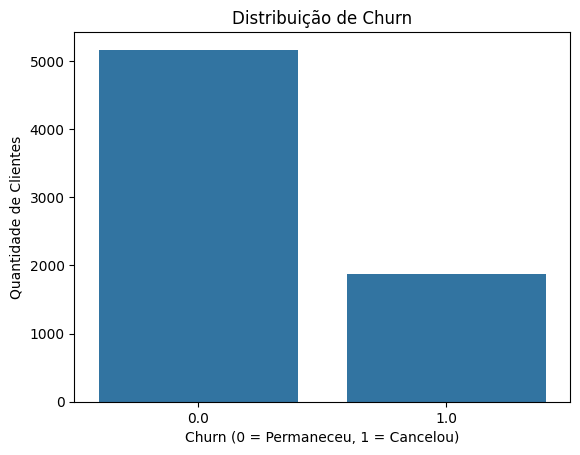

In [34]:
# Criar gráfico de barras
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn', data=df)

plt.title('Distribuição de Churn')
plt.xlabel('Churn (0 = Permaneceu, 1 = Cancelou)')
plt.ylabel('Quantidade de Clientes')

# salvar imagem
plt.savefig('distribuicao_churn.png')

plt.show()

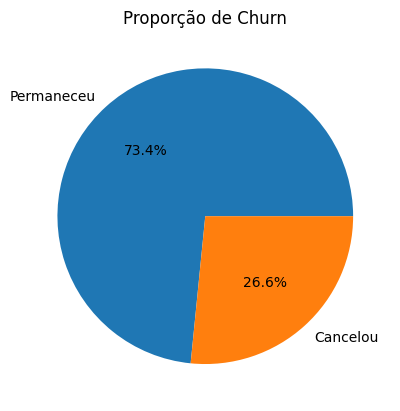

In [35]:
# Gráfico de pizza
import os
import matplotlib.pyplot as plt

# criar pasta se não existir
os.makedirs('imagens', exist_ok=True)

df['Churn'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['Permaneceu', 'Cancelou']
)

plt.title('Proporção de Churn')
plt.ylabel('')

# salvar imagem
plt.savefig('imagens/proporcao_churn.png', dpi=300, bbox_inches='tight')

plt.show()

## Distribuição da Evasão (Churn)

Foi analisada a distribuição da variável `Churn` para entender a proporção de clientes que permaneceram e os que cancelaram o serviço.

Observa-se que a maioria dos clientes permanece na empresa, porém aproximadamente **26% dos clientes cancelaram o serviço**, indicando uma taxa relevante de evasão.

Essa análise inicial ajuda a compreender a dimensão do problema e reforça a importância de investigar quais fatores influenciam o cancelamento dos clientes.

# 12. Contagem de Evasão por Variáveis Categóricas

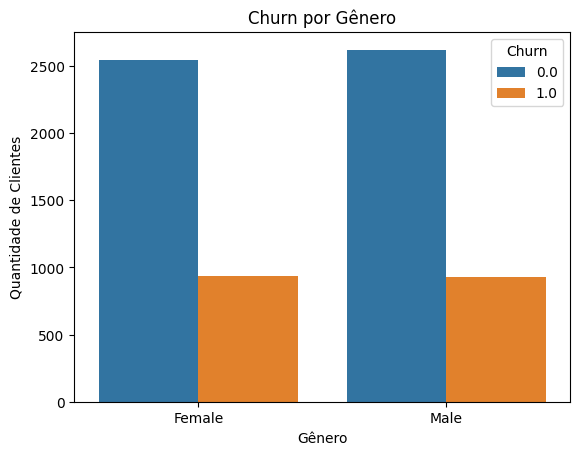

In [36]:
# Exemplo com gênero
sns.countplot(x='customer_gender', hue='Churn', data=df)

plt.title('Churn por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade de Clientes')

plt.savefig('imagens/churn_genero.png', dpi=300, bbox_inches='tight')

plt.show()

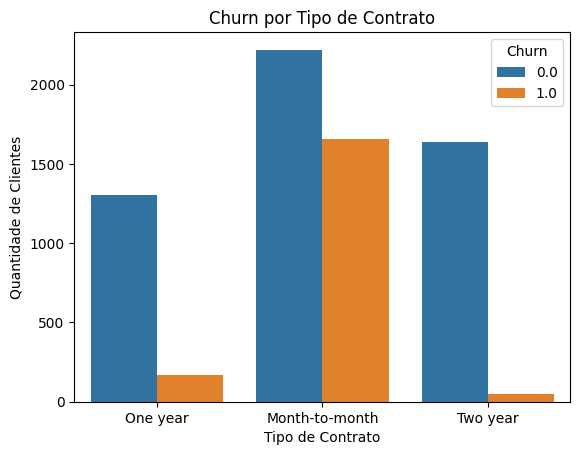

In [37]:
# Tipo de contrato
sns.countplot(x='account_Contract', hue='Churn', data=df)

plt.title('Churn por Tipo de Contrato')
plt.xlabel('Tipo de Contrato')
plt.ylabel('Quantidade de Clientes')

plt.savefig('imagens/churn_contrato.png', dpi=300, bbox_inches='tight')

plt.show()

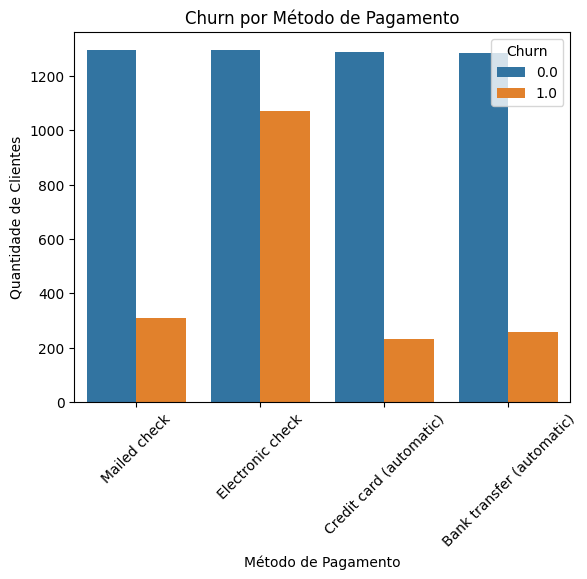

In [38]:
# Método de pagamento
sns.countplot(x='account_PaymentMethod', hue='Churn', data=df)

plt.title('Churn por Método de Pagamento')
plt.xlabel('Método de Pagamento')
plt.ylabel('Quantidade de Clientes')

plt.xticks(rotation=45)

plt.savefig('imagens/churn_pagamento.png', dpi=300, bbox_inches='tight')

plt.show()

## Contagem de Evasão por Variáveis Categóricas

Foram analisadas algumas variáveis categóricas para verificar como a evasão de clientes se distribui entre diferentes perfis.

Essa análise permite identificar padrões de cancelamento associados a características específicas dos clientes, como gênero, tipo de contrato e método de pagamento.

A visualização desses dados auxilia na identificação de fatores que podem influenciar a decisão de cancelamento do serviço.

In [39]:
# para garantir que as bibliotecas estão carregadas
import seaborn as sns
import matplotlib.pyplot as plt

## Análise de Evasão por Variáveis Categóricas

Nesta etapa da análise exploratória, foram avaliadas algumas variáveis categóricas para entender como elas se relacionam com a evasão de clientes (churn). Os gráficos apresentados mostram a distribuição de clientes que permaneceram no serviço e aqueles que cancelaram.

---

### 1. Churn por Gênero

O gráfico de churn por gênero mostra a quantidade de clientes que permaneceram e cancelaram o serviço entre homens e mulheres.

Observa-se que a distribuição de churn é bastante semelhante entre os dois grupos. Tanto clientes do gênero masculino quanto feminino apresentam números próximos de cancelamento.

Isso indica que o **gênero não parece ser um fator determinante para a evasão de clientes**, pois não há uma diferença significativa entre os grupos analisados.

---

### 2. Churn por Tipo de Contrato

A análise por tipo de contrato revela um padrão mais evidente no comportamento de evasão.

Clientes com contrato **Month-to-month (mensal)** apresentam a maior quantidade de cancelamentos. Isso sugere que contratos de curta duração oferecem maior flexibilidade para o cliente interromper o serviço.

Por outro lado, clientes com contratos de **One year** e **Two year** apresentam níveis muito menores de churn. Esse comportamento indica que contratos de longo prazo contribuem para maior fidelização dos clientes.

Esse resultado sugere que incentivar contratos mais longos pode ser uma estratégia eficaz para reduzir a evasão.

---

### 3. Churn por Método de Pagamento

O gráfico que analisa o método de pagamento mostra diferenças mais claras entre os grupos.

Clientes que utilizam **Electronic check** apresentam uma quantidade significativamente maior de cancelamentos em comparação com os outros métodos de pagamento.

Já clientes que utilizam **Credit card (automatic)** e **Bank transfer (automatic)** demonstram menor taxa de evasão. Isso pode estar relacionado ao fato de que pagamentos automáticos tendem a facilitar a continuidade do serviço.

O método **Mailed check** apresenta uma taxa intermediária de cancelamento.

---

### Conclusão Parcial

A partir da análise dessas variáveis categóricas, é possível observar que:

- O **gênero não apresenta influência significativa no churn**.
- O **tipo de contrato tem forte impacto na evasão**, com maior churn em contratos mensais.
- O **método de pagamento também influencia o churn**, especialmente no caso de pagamentos via electronic check.

Esses insights podem ajudar a empresa a desenvolver estratégias de retenção, como incentivar contratos de maior duração e promover métodos de pagamento automáticos.

# 13. Contagem de Evasão por Variáveis Numéricas

In [40]:
df.columns


Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')

In [41]:
print(df.columns)

Index(['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen',
       'customer_Partner', 'customer_Dependents', 'customer_tenure',
       'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService',
       'internet_OnlineSecurity', 'internet_OnlineBackup',
       'internet_DeviceProtection', 'internet_TechSupport',
       'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract',
       'account_PaperlessBilling', 'account_PaymentMethod',
       'account_Charges_Monthly', 'account_Charges_Total', 'Contas_Diarias'],
      dtype='object')


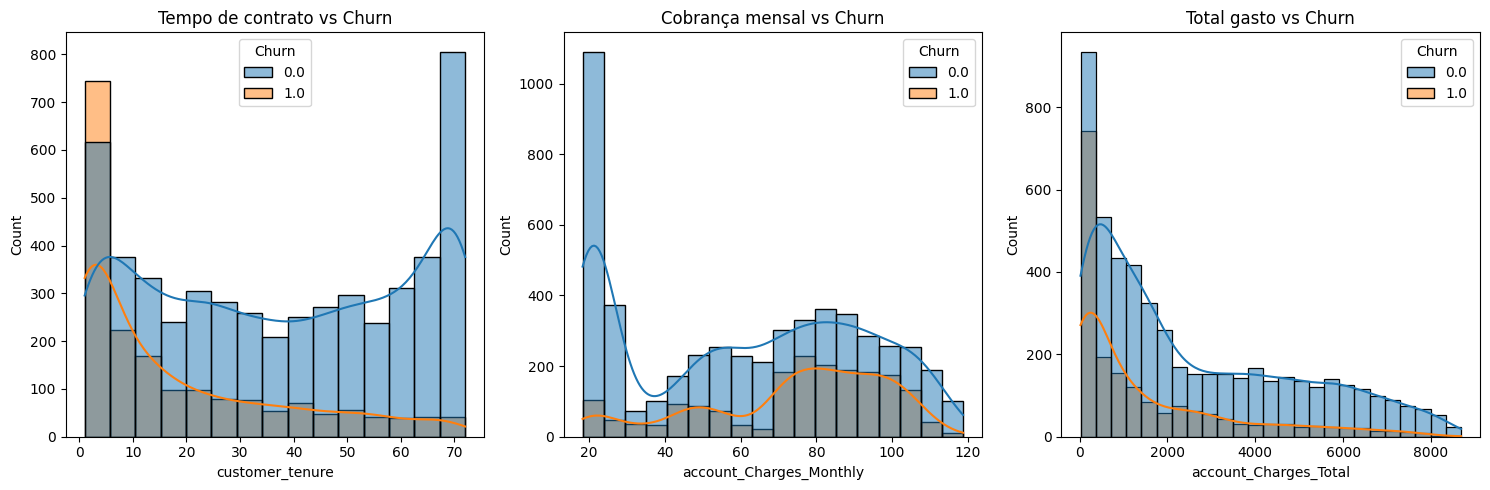

In [43]:
# Gráficos
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
sns.histplot(data=df, x='customer_tenure', hue='Churn', kde=True)
plt.title('Tempo de contrato vs Churn')

plt.subplot(1,3,2)
sns.histplot(data=df, x='account_Charges_Monthly', hue='Churn', kde=True)
plt.title('Cobrança mensal vs Churn')

plt.subplot(1,3,3)
sns.histplot(data=df, x='account_Charges_Total', hue='Churn', kde=True)
plt.title('Total gasto vs Churn')

plt.tight_layout()

# salvar imagem
plt.savefig('imagens/churn_variaveis_numericas.png', dpi=300, bbox_inches='tight')

plt.show()


## Análise de Evasão por Variáveis Numéricas

Nesta etapa da análise exploratória, foram analisadas algumas variáveis numéricas para entender como elas se relacionam com a evasão de clientes (churn).

Para esta análise, a variável **Churn** está codificada da seguinte forma:

- **0 → Cliente permaneceu no serviço**
- **1 → Cliente cancelou o serviço (evasão)**

As variáveis analisadas foram:

- **customer_tenure**: tempo de permanência do cliente na empresa (em meses).
- **account_Charges_Monthly**: valor da cobrança mensal do serviço.
- **account_Charges_Total**: valor total gasto pelo cliente desde o início do contrato.

Os gráficos de distribuição permitem comparar como esses valores se comportam entre clientes que **cancelaram o serviço (Churn = 1)** e aqueles que **permaneceram (Churn = 0)**.

---

## Interpretação dos Gráficos

### Tempo de Permanência (customer_tenure)

Observa-se que clientes com **Churn = 1** tendem a ter menor tempo de permanência na empresa. A maior concentração de cancelamentos ocorre nos primeiros meses de contrato.

Já clientes com **Churn = 0** apresentam maior tempo de permanência, indicando maior fidelização ao serviço.

---

### Cobrança Mensal (account_Charges_Monthly)

A distribuição da cobrança mensal sugere que clientes com **valores mensais mais elevados** apresentam uma tendência ligeiramente maior de churn (**Churn = 1**).

Isso pode indicar que planos com custos mais altos podem influenciar a decisão de cancelamento quando o cliente não percebe valor suficiente no serviço.

---

### Total Gasto (account_Charges_Total)

Clientes com **Churn = 0** tendem a apresentar valores totais gastos mais elevados, o que é esperado, já que permanecem mais tempo utilizando o serviço.

Já clientes com **Churn = 1** geralmente apresentam valores totais menores, refletindo um tempo de permanência mais curto.

---

## Conclusão da Análise

A análise das variáveis numéricas sugere que o **tempo de permanência do cliente é um fator importante na evasão**. Clientes com menor tempo de contrato apresentam maior probabilidade de cancelar o serviço.

Além disso, valores mensais mais altos podem estar associados a uma maior taxa de evasão. Esses insights podem ajudar a empresa a desenvolver estratégias de retenção, especialmente focadas nos **primeiros meses de relacionamento com o cliente**.



# 14. Relatório

# Relatório Final — Análise de Evasão de Clientes (Churn)

## 1. Introdução

A evasão de clientes, também conhecida como **churn**, representa um dos principais desafios para empresas que oferecem serviços por assinatura. Quando um cliente cancela o serviço, a empresa perde receita e precisa investir mais recursos para conquistar novos clientes.

O objetivo deste projeto foi analisar um conjunto de dados de clientes de uma empresa de telecomunicações para identificar **padrões e fatores associados à evasão de clientes**. A partir dessa análise, buscamos gerar insights que possam auxiliar na criação de estratégias de retenção.

---

## 2. Limpeza e Tratamento de Dados

Antes da análise, foi necessário realizar algumas etapas de preparação dos dados para garantir sua qualidade e consistência.

As principais etapas realizadas foram:

- Importação da base de dados para o ambiente de análise.
- Verificação da estrutura do dataset e dos tipos de variáveis.
- Tratamento de valores ausentes.
- Padronização e organização dos nomes das colunas.
- Conversão de variáveis para os formatos apropriados para análise.

Além disso, a variável **Churn**, que indica a evasão de clientes, foi codificada da seguinte forma:

- **0 → Cliente permaneceu no serviço**
- **1 → Cliente cancelou o serviço**

Esse tratamento permitiu realizar análises e visualizações de forma mais consistente.

---

## 3. Análise Exploratória de Dados

A análise exploratória foi realizada com o objetivo de entender melhor o comportamento dos clientes e identificar possíveis padrões relacionados à evasão.

Foram analisadas tanto **variáveis categóricas** quanto **variáveis numéricas**.

### Variáveis Categóricas

Foram avaliadas variáveis como:

- Gênero do cliente
- Tipo de contrato
- Método de pagamento

Os gráficos indicaram que:

- O **gênero** não apresenta diferença significativa na taxa de evasão.
- Clientes com contrato **Month-to-month (mensal)** apresentam maior taxa de churn.
- O método de pagamento **Electronic Check** apresenta maior proporção de cancelamentos em comparação com métodos automáticos.

### Variáveis Numéricas

Também foram analisadas variáveis relacionadas ao comportamento financeiro e ao tempo de permanência do cliente, como:

- **Tempo de contrato (customer_tenure)**
- **Cobrança mensal (account_Charges_Monthly)**
- **Valor total gasto (account_Charges_Total)**

A análise mostrou que:

- Clientes que cancelam tendem a ter **menor tempo de permanência na empresa**.
- Valores mensais mais elevados apresentam uma **tendência maior de churn**.
- Clientes que permanecem na empresa tendem a apresentar **maior valor total gasto**, refletindo maior tempo de relacionamento com a empresa.

Essas análises foram apoiadas por gráficos que ajudam a visualizar essas distribuições.

---

## 4. Conclusões e Insights

A análise exploratória revelou alguns padrões importantes relacionados à evasão de clientes.

Entre os principais insights identificados:

- **Clientes com contratos mensais apresentam maior probabilidade de cancelar o serviço.**
- **Clientes com menor tempo de permanência na empresa apresentam maior taxa de churn.**
- **Métodos de pagamento automáticos parecem estar associados a menor evasão.**
- **Clientes com cobranças mensais mais altas podem apresentar maior tendência ao cancelamento.**

Esses fatores indicam que tanto o **tempo de relacionamento com o cliente** quanto o **tipo de contrato** influenciam significativamente na probabilidade de evasão.

---

## 5. Recomendações

Com base nos insights obtidos a partir da análise dos dados, algumas estratégias podem ser consideradas pela empresa para reduzir a evasão de clientes:

- **Incentivar contratos de longo prazo**, oferecendo benefícios ou descontos para planos anuais.
- **Criar estratégias de retenção nos primeiros meses de contrato**, período em que ocorre maior concentração de cancelamentos.
- **Incentivar o uso de métodos de pagamento automáticos**, que parecem estar associados a menor taxa de churn.
- **Avaliar a percepção de valor dos planos com mensalidades mais altas**, garantindo que o cliente perceba benefícios compatíveis com o custo do serviço.

Essas ações podem contribuir para melhorar a retenção de clientes e reduzir o impacto da evasão na receita da empresa.

---

## 6. Considerações Finais

A análise exploratória de dados permitiu identificar padrões importantes no comportamento dos clientes e fatores que podem influenciar a decisão de cancelamento.

Esses insights podem servir como base para análises mais avançadas, como a construção de **modelos de machine learning para previsão de churn**, permitindo que a empresa identifique clientes com maior risco de evasão e atue preventivamente.